   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


c:\Users\Tanaya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tanaya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tanaya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tanaya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Wi

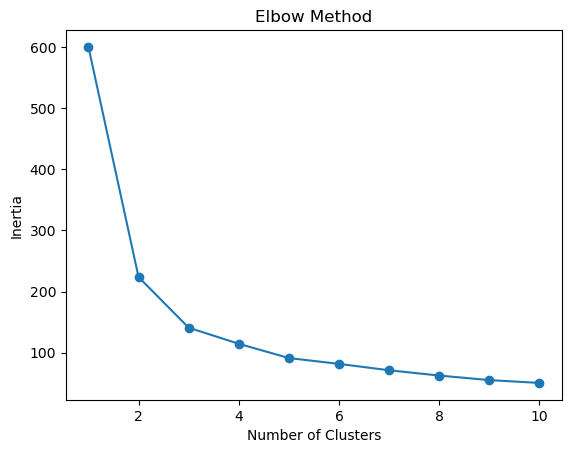

c:\Users\Tanaya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Clustered Data:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Cluster
0             5.1           3.5            1.4           0.2        1
1             4.9           3.0            1.4           0.2        1
2             4.7           3.2            1.3           0.2        1
3             4.6           3.1            1.5           0.2        1
4             5.0           3.6            1.4           0.2        1
5             5.4           3.9            1.7           0.4        1
6             4.6           3.4            1.4           0.3        1
7             5.0           3.4            1.5           0.2        1
8             4.4           2.9            1.4           0.2        1
9             4.9           3.1            1.5           0.1        1
10            5.4           3.7            1.5           0.2        1
11            4.8           3.4            1.6           0.2        1
12            4.8           3.0            1.4           0.1        1
13 

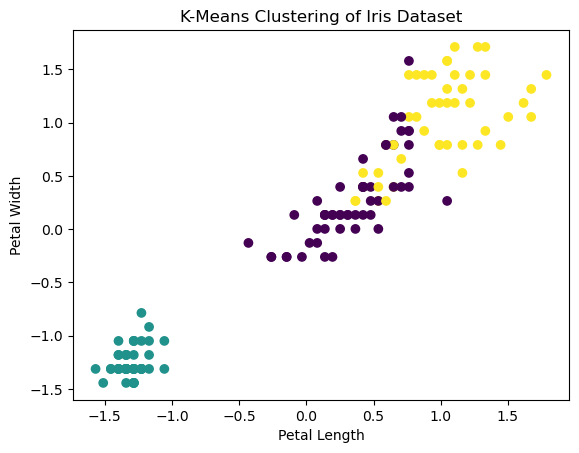

In [1]:
# K-Means Clustering on Iris Dataset
# Determine number of clusters using Elbow Method

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
data = pd.read_csv("Iris.csv")

# Display first 5 rows
print(data.head())

# 2. Select numerical features
X = data[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# 3. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Find the optimal number of clusters using Elbow Method
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# 5. Plot Elbow Curve
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# 6. Apply K-Means with optimal number of clusters
# From the elbow graph, k = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# 7. Add cluster numbers to dataset
data["Cluster"] = clusters

# 8. Display results
print("\nClustered Data:")
print(data[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
    "Cluster"
]].head(20))

# 9. Visualize clusters
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=clusters
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering of Iris Dataset")
plt.show()